## jit function

In [1]:
import jax.numpy as jnp
from jax import jit

def slow_function(x):
    return jnp.sum(x ** 2)

fast_function = jit(slow_function)

import time
x = jnp.arange(1000000000)

# Without jit
start = time.time()
print(slow_function(x))
print("Without jit:", time.time() - start)

# With jit (first call compiles)
start = time.time()
print(fast_function(x))
print("With jit (first call):", time.time() - start)

# Subsequent calls (fast)
start = time.time()
print(fast_function(x))
print("With jit (second call):", time.time() - start)


-2087553280
Without jit: 0.8015718460083008
-2087553280
With jit (first call): 0.9595470428466797
-2087553280
With jit (second call): 0.8819043636322021


In [2]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt

# Hamiltonian function
def H(z):
    q, p = z[..., 0], z[..., 1]
    return 0.5 * p**2 + 0.5 * q**2

# Hamiltonian dynamics function returns time derivative dz/dt
def hamiltonian_dynamics(H, z, t=0):
    # z = [q, p], shape (..., 2)
    q, p = z[..., 0], z[..., 1]

    # Compute gradients w.r.t. q and p
    dH_dz = jax.grad(H)(z)

    dH_dq = dH_dz[..., 0]
    dH_dp = dH_dz[..., 1]

    # Hamilton's equations: dq/dt = dH/dp, dp/dt = -dH/dq
    dq_dt = dH_dp
    dp_dt = -dH_dq

    dz_dt = jnp.stack([dq_dt, dp_dt], axis=-1)
    return dz_dt


In [3]:
def BHamiltonianFlow(H, z0, T, tol=1e-5):
    # Batched vectorized and JIT compiled dynamics
    dynamics = jit(vmap(jit(partial(hamiltonian_dynamics, H)), (0, None)))
    # Solve ODE for batch over time T
    traj = odeint(dynamics, z0, T, rtol=tol)
    return traj.transpose((1, 0, 2))  # shape: (batch, time, state_dim)


trajectories shape: (3, 100, 2)


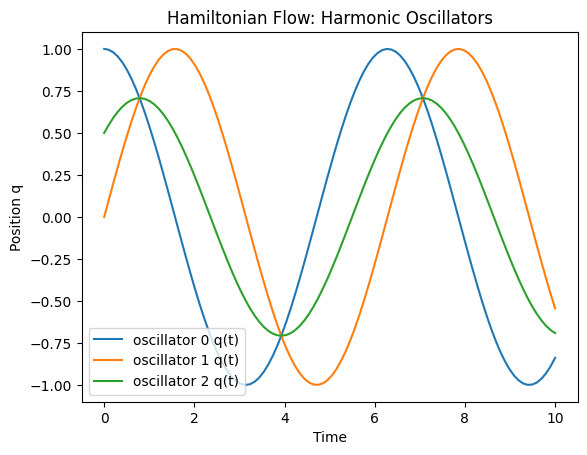

In [4]:
# Initial conditions for 3 oscillators (batch size = 3)
z0 = jnp.array([
    [1.0, 0.0],   # Start at q=1, p=0
    [0.0, 1.0],   # Start at q=0, p=1
    [0.5, 0.5],   # Start at q=0.5, p=0.5
])

# Times to simulate (0 to 10 in 100 steps)
T = jnp.linspace(0, 10, 100)

# Compute trajectories
trajectories = BHamiltonianFlow(H, z0, T)

print("trajectories shape:", trajectories.shape)  # (3, 100, 2)

# Plot q(t) for each oscillator
for i in range(z0.shape[0]):
    plt.plot(T, trajectories[i, :, 0], label=f'oscillator {i} q(t)')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Position q")
plt.title("Hamiltonian Flow: Harmonic Oscillators")
plt.show()
